


















































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































# Base Telco Customer




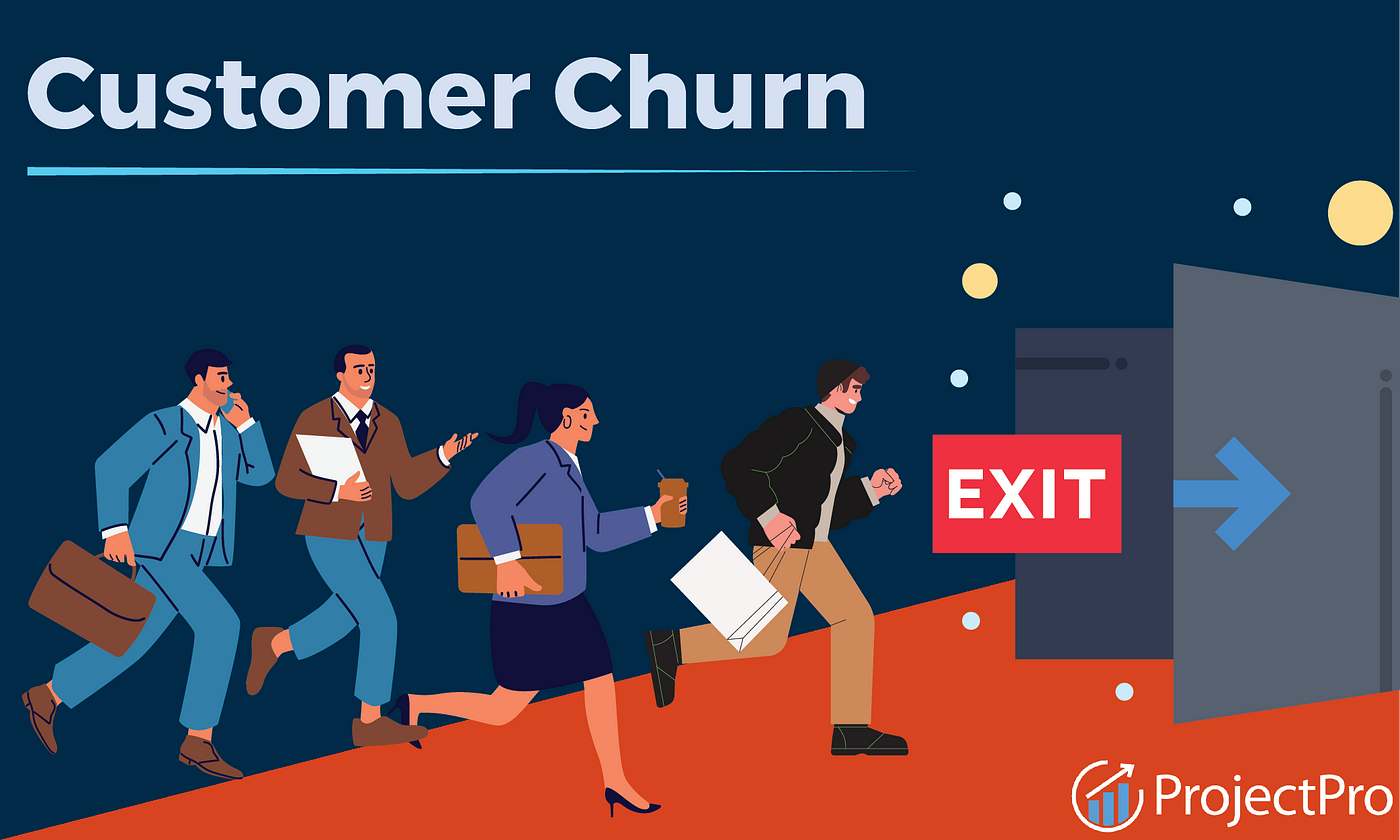

Este notebook tem como objetivo explorar o dataset Telco Customer Churn, que contém informações sobre clientes de uma empresa de telecomunicações fictícia, com foco na previsão de rotatividade (churn). O dataset é composto por 7.043 registros e 21 colunas, incluindo variáveis demográficas (ex.: gênero, idade), serviços contratados (ex.: tipo de internet, suporte técnico), informações de conta (ex.: tipo de contrato, mensalidade) e a variável alvo Churn (indica se o cliente abandonou a empresa).

A exploração será conduzida por meio de análise exploratória de dados (EDA) para identificar padrões, correlações e fatores que influenciam o churn, como tempo de permanência, tipo de contrato e serviços adicionais. Além disso, serão aplicadas técnicas de pré-processamento (tratamento de valores nulos, codificação de variáveis categóricas, normalização) e feature engineering para preparar o dataset para modelagem. O objetivo final é construir um modelo de classificação supervisionada capaz de prever o churn com alta precisão, utilizando algoritmos como Regressão Logística, Random Forest e XGBoost, e avaliando métricas como AUC-ROC, F1-Score e Recall, especialmente para a classe minoritária (Churn = Yes).

Os insights gerados serão usados para propor estratégias de retenção, como oferecer contratos de longo prazo ou melhorar serviços críticos, contribuindo para a redução da taxa de churn e informando decisões de negócio baseadas em dados.

**📄 Identificação do Cliente**

- **customerID:** Identificador único de cada cliente

**👤 Informações Demográficas**

- **gender:** Gênero do cliente (Masculino/Feminino).

- **SeniorCitizen:** Indica se o cliente é idoso (1) ou não (0).

- **Partner:** Indica se o cliente possui parceiro ou cônjuge (Sim/Não).

- **Dependents:** Indica se o cliente possui dependentes (Sim/Não)

**🏠 Informações de Conta**

- **tenure:** Número de meses que o cliente está com a empresa.

- **Contract:** Tipo de contrato (Mensal, Um ano, Dois anos).

- **PaperlessBilling:** Indica se o cliente optou por fatura sem papel (Sim/Não).

- **PaymentMethod:** Método de pagamento utilizado (e.g., Débito automático, Cartão de crédito, Boleto bancário).


**💰 Informações Financeiras**

- **MonthlyCharges:** Valor cobrado mensalmente ao cliente.

- **TotalCharges:** Valor total cobrado ao cliente até o momento

**📡 Serviços Contratados**

- **PhoneService:** Indica se o cliente possui serviço telefônico (Sim/Não).

- **MultipleLines:** Indica se o cliente possui múltiplas linhas telefônicas (Sim/Não/Não disponível).

- **InternetService:** Tipo de serviço de internet (DSL, Fibra óptica, Nenhum).

- **OnlineSecurity:** Indica se o cliente possui serviço de segurança online (Sim/Não/Não disponível).

- **OnlineBackup:** Indica se o cliente possui serviço de backup online (Sim/Não/Não disponível).

- **DeviceProtection:** Indica se o cliente possui proteção de dispositivo (Sim/Não/Não disponível).

- **TechSupport:** Indica se o cliente possui suporte técnico (Sim/Não/Não disponível).

- **StreamingTV:** Indica se o cliente possui serviço de streaming de TV (Sim/Não/Não disponível).

- **StreamingMovies:** Indica se o cliente possui serviço de streaming de filmes (Sim/Não/Não disponível).

# Análises a serem feitas




**🔎 1️⃣ Análises Univariadas:**

- Distribuição de variáveis categóricas como **gender**, **SeniorCitizen**, **Partner**, **Dependents** e **InternetService**.

- Análise de densidade e distribuição para variáveis numéricas como **tenure**, **MonthlyCharges** e **TotalCharges**.

- Taxa de cancelamento (Churn) global e segmentada.



**🔄 2️⃣ Análises Bivariadas:**

- **Churn vs. Contract Type:** Tipos de contrato influenciam na taxa de cancelamento? Clientes com contratos mensais tendem a cancelar mais?

- **Churn vs. InternetService:** Clientes de Fibra Óptica cancelam mais que DSL?

- **Churn vs. PaymentMethod:** O método de pagamento (automático, boleto, cartão) impacta na retenção?

- **MonthlyCharges vs. Churn:** Há correlação entre o valor mensal pago e o cancelamento?

- **tenure vs. Churn:** Clientes com maior tempo de casa cancelam menos?

- **Services QTD vs Churn:**Quantos serviços a pessoa contratou e o quanto a quantidade de serviços contratados influencia no Churn

- **Service Type vs Churn:** qual a proporção de pessoas que contrataram X serviço churnaram.

**👥 3️⃣ Análises Multivariadas:**

- **Contract + InternetService + Churn:** Existe um padrão entre o tipo de internet e o contrato que aumenta a chance de cancelamento?

- **PaymentMethod + PaperlessBilling + Churn:** Pagamento automático versus boleto e suas relações com cancelamento.

- **SeniorCitizen + Dependents + Churn:** Idosos sem dependentes cancelam mais?

- **TechSupport + OnlineSecurity + Churn:** A ausência desses serviços aumenta a chance de churn?



**📊4️⃣ Análises de Correlação:**

- Matriz de correlação para identificar relações lineares entre as variáveis numéricas (tenure, MonthlyCharges, TotalCharges).

- Análise de correlação entre serviços contratados e a taxa de cancelamento.



🔍 5️⃣ Outras análises:

**Serviços Mais Contratados vs. Churn:**

- **Análise:** Identificar os serviços mais populares e verificar se esses serviços possuem uma taxa de churn elevada.

- **Objetivo:** Descobrir quais serviços possuem maior retenção ou evasão de clientes.

- **Visualização sugerida:** Barplot para popularidade dos serviços e taxa de churn associada.



**Serviços Contratados por Gênero, SeniorCitizen e Dependents:**

- **Análise:** Verificar se há diferenças significativas nos serviços contratados com base em:

 - **Gênero (gender)**

 - **Idosos (SeniorCitizen)**

 - **Dependentes (Dependents)**

- **Objetivo:** Identificar perfis de consumo de serviços específicos para cada grupo.

- **Visualização sugerida:** Heatmap ou stacked bar plot para visualizar essas diferenças.

# Importação das bibliotecas básicas

In [1]:
!pip install optuna-integration[sklearn]

In [2]:
!pip install optuna


In [3]:
!pip -q install plotly --upgrade

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
plotly-resampler 0.10.0 requires plotly<6.0.0,>=5.5.0, but you have plotly 6.2.0 which is incompatible.


In [4]:
!pip -q install yellowbrick

In [5]:
!pip install pycaret

  Using cached plotly-5.24.1-py3-none-any.whl.metadata (7.3 kB)
Using cached plotly-5.24.1-py3-none-any.whl (19.1 MB)
  Attempting uninstall: plotly
    Found existing installation: plotly 6.2.0
    Uninstalling plotly-6.2.0:
      Successfully uninstalled plotly-6.2.0


In [123]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency
import pickle
from pycaret.classification import get_config
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split







In [7]:
base_telco_df = pd.read_csv('telco_customer_churn.csv')

# Exploração dos dados

### Estatísticas básicas

In [8]:
base_telco_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
# Resumo geral
print("📊 Informações básicas:")
print(base_telco_df.info())
print("\n🔍 Estatísticas descritivas:")
print(base_telco_df.describe)

In [ ]:
# Tipos de dados
print("\n📦 Tipos de dados por coluna:")
print(base_telco_df.dtypes)

In [ ]:
# Valores únicos por coluna
print("\n🔑 Contagem de valores únicos por coluna:")
print(base_telco_df.nunique())

In [ ]:
# Valores nulos
print("\n⚠️ Valores nulos por coluna:")
null_count = base_telco_df.isnull().sum()
null_percent = (null_count / len(base_telco_df)) * 100
null_df = pd.DataFrame({'Nulos': null_count, '% Nulos': null_percent})
print(null_df[null_df['Nulos'] > 0])

In [ ]:

# Cardinalidade (somente colunas categóricas)
print("\n🔠 Cardinalidade de colunas categóricas:")
cat_cols = base_telco_df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    print(f"{col}: {base_telco_df[col].nunique()} categorias")

In [ ]:
# Correlações numéricas
print("\n📈 Correlação entre variáveis numéricas:")
corr = base_telco_df.corr(numeric_only=True)
print(corr)

In [ ]:
# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de Correlação")
plt.tight_layout()
plt.show()


In [ ]:
# Valores duplicados
print("\n🔁 Duplicatas:")
print(f"Linhas duplicadas: {base_telco_df.duplicated().sum()}")

📊 Informações básicas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7

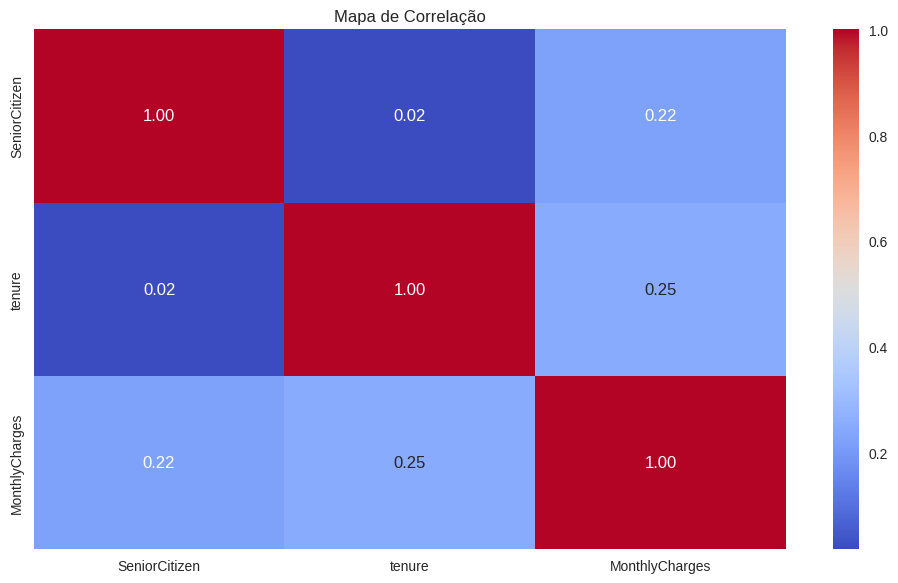


🔁 Duplicatas:
Linhas duplicadas: 0

📌 Amostra dos dados:
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
941   0811-GSDTP  Female              0      No        Yes      13   
1404  1970-KKFWL  Female              0      No         No      35   
5515  2892-GESUL  Female              0     Yes        Yes      18   
3684  2842-BCQGE    Male              0      No         No      43   
7017  4807-IZYOZ  Female              0      No         No      51   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
941            No  No_phone_service             DSL                   No  ...   
1404          Yes               Yes              No  No_internet_service  ...   
5515          Yes                No              No  No_internet_service  ...   
3684          Yes               Yes     Fiber_optic                   No  ...   
7017          Yes                No              No  No_internet_service  ...   

         DeviceProtection         

In [66]:

# Amostra dos dados
print("\n📌 Amostra dos dados:")
print(base_telco_df.sample(5))

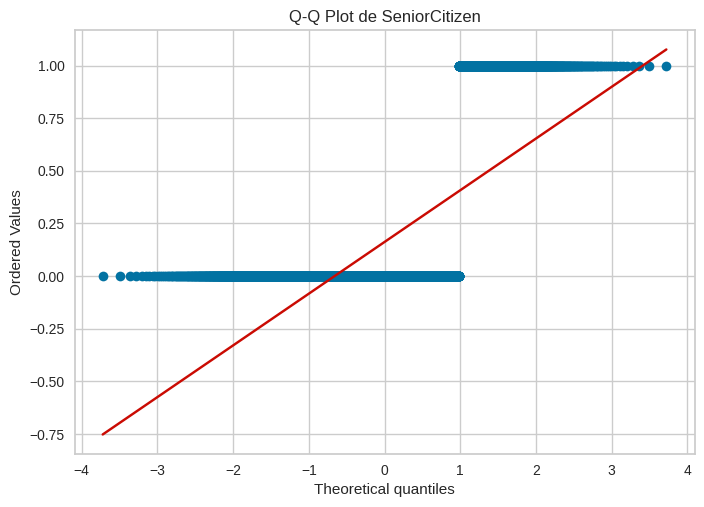

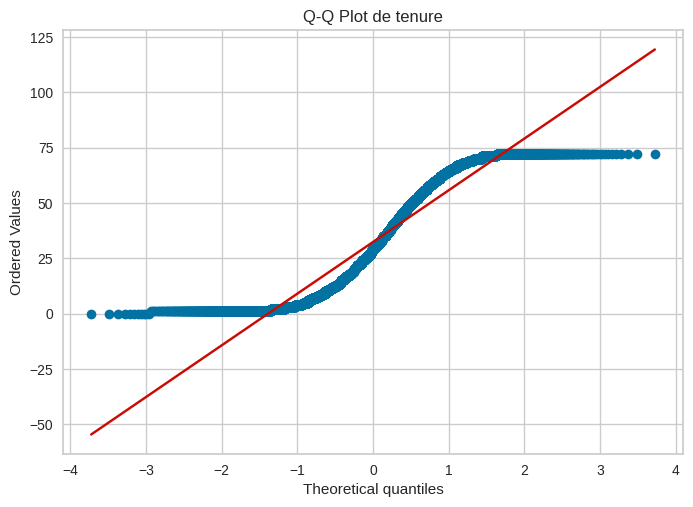

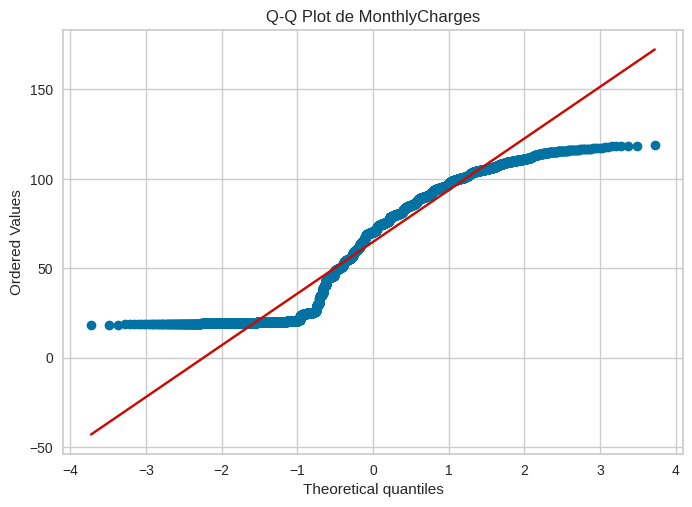

In [14]:
#verificando normalidade gaussiana
numeric_cols = base_telco_df.select_dtypes(include=['int64', 'float64']).columns

import scipy.stats as stats
import matplotlib.pyplot as plt
for col in numeric_cols:
    stats.probplot(base_telco_df[col], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot de {col}')
    plt.show()

### Visualização dos dados


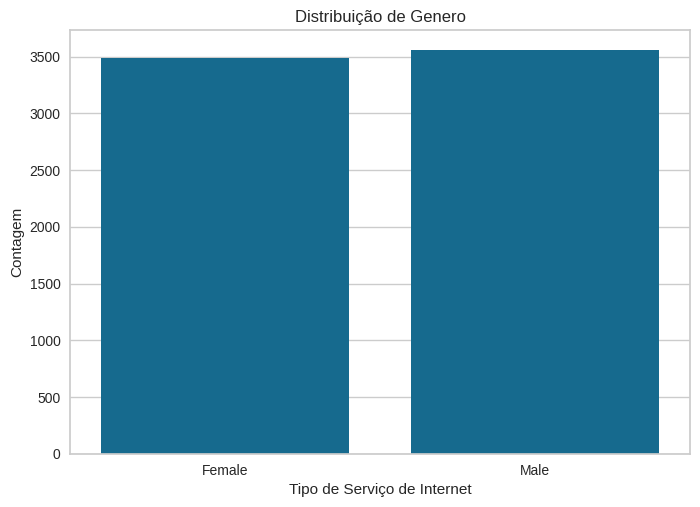

In [15]:
sns.countplot(x='gender', data=base_telco_df)
plt.title('Distribuição de Genero')
plt.xlabel('Tipo de Serviço de Internet')
plt.ylabel('Contagem')
plt.show()

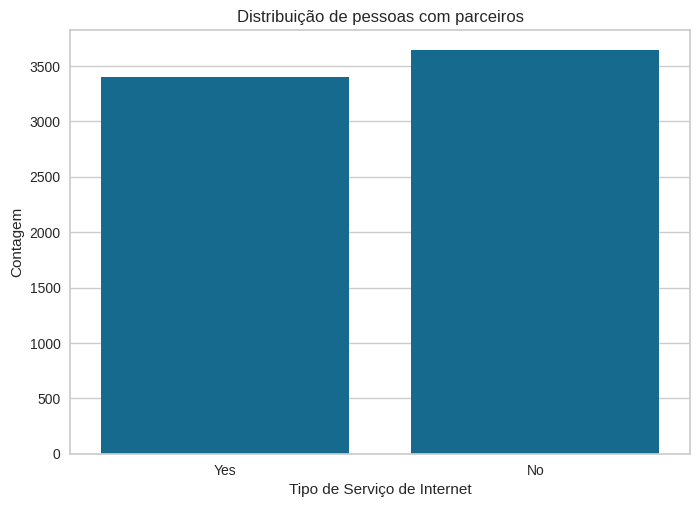

In [16]:
sns.countplot(x='Partner', data=base_telco_df)
plt.title('Distribuição de pessoas com parceiros')
plt.xlabel('Tipo de Serviço de Internet')
plt.ylabel('Contagem')
plt.show()

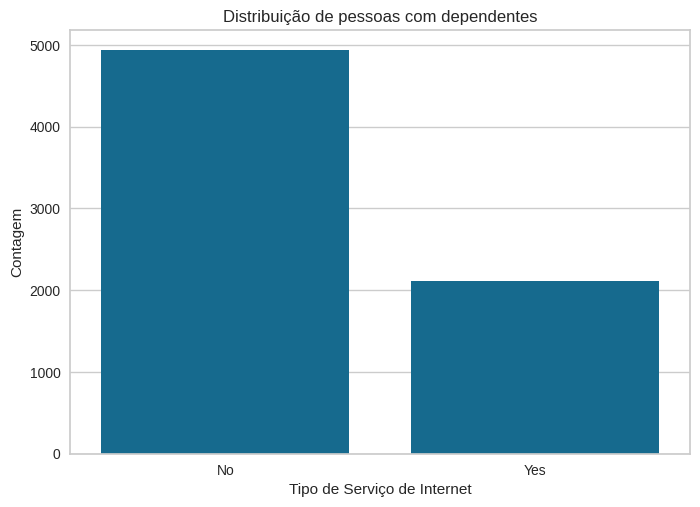

In [17]:
sns.countplot(x='Dependents', data=base_telco_df)
plt.title('Distribuição de pessoas com dependentes')
plt.xlabel('Tipo de Serviço de Internet')
plt.ylabel('Contagem')
plt.show()

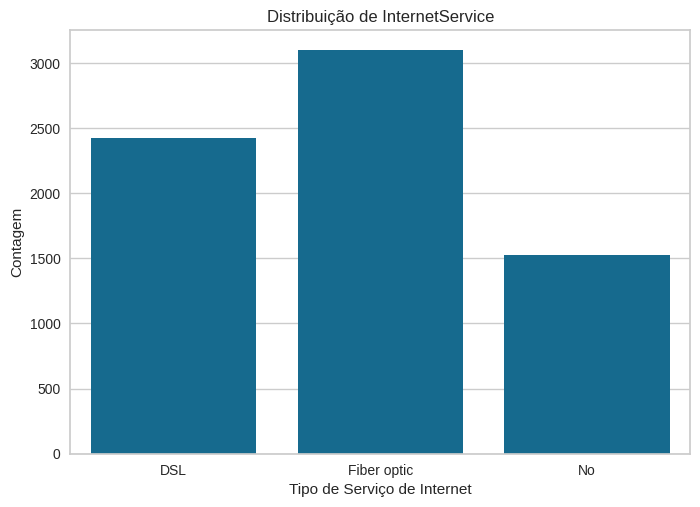

In [18]:
sns.countplot(x='InternetService', data=base_telco_df)
plt.title('Distribuição de InternetService')
plt.xlabel('Tipo de Serviço de Internet')
plt.ylabel('Contagem')
plt.show()

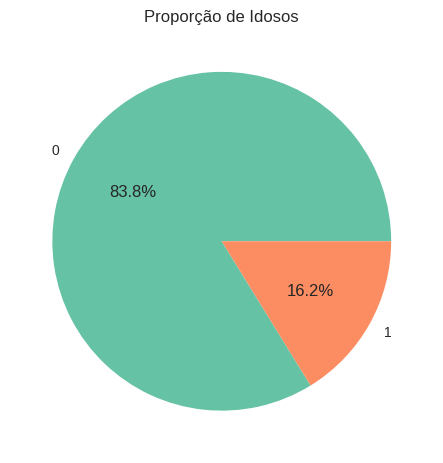

In [19]:
base_telco_df['SeniorCitizen'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66c2a5','#fc8d62'])
plt.title('Proporção de Idosos')
plt.ylabel('')  # Remove o label para melhor visualização
plt.show()


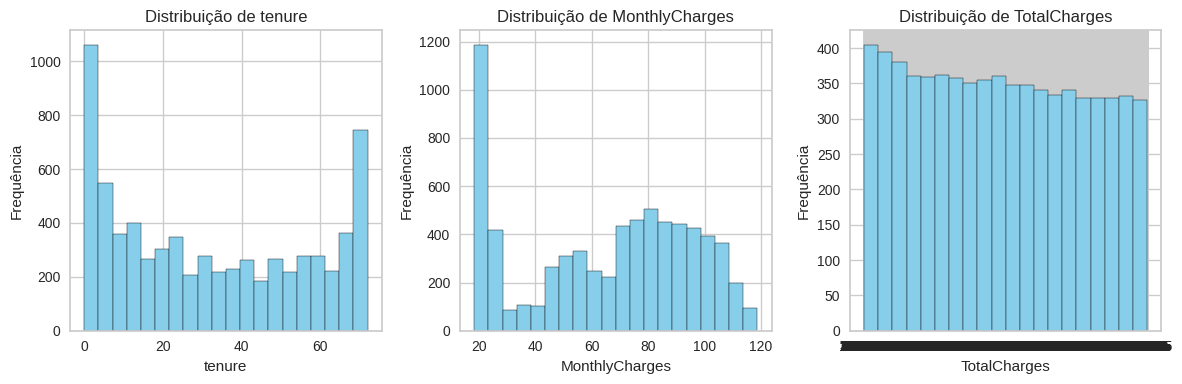

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    plt.subplot(1, 3, i + 1)
    plt.hist(base_telco_df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
plt.tight_layout()
plt.show()


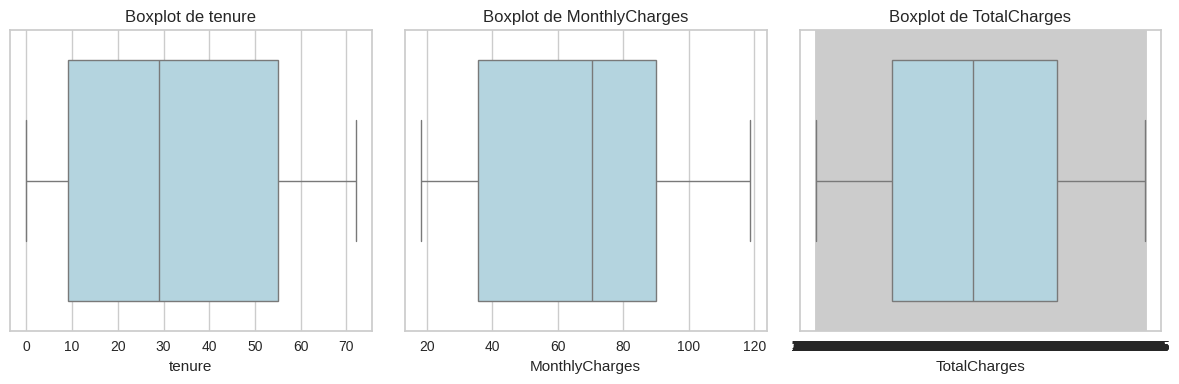

In [21]:
plt.figure(figsize=(12, 4))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=base_telco_df[col], color='lightblue')
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()


In [22]:
# Taxa de cancelamento global
churn_rate = base_telco_df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


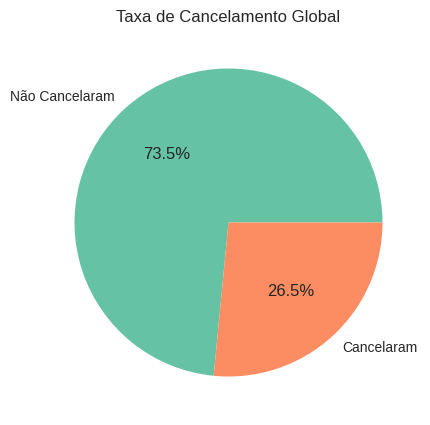

In [23]:

labels = ['Não Cancelaram', 'Cancelaram']
plt.figure(figsize=(5, 5))
plt.pie(churn_rate, labels=labels, autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'])
plt.title('Taxa de Cancelamento Global')
plt.show()

#### Visualização de relações Bivariadas

**Taxa de Cancelamento Segmentada**

#####➡️ Churn por Gênero (gender)

In [24]:
churn_rate_gender = base_telco_df.groupby('gender')['Churn'].value_counts(normalize=True).unstack() * 100

In [25]:
churn_rate_gender

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [26]:
churn_rate_gender = churn_rate_gender['Yes'].reset_index().rename(columns={'Yes': 'Churn_Rate'})

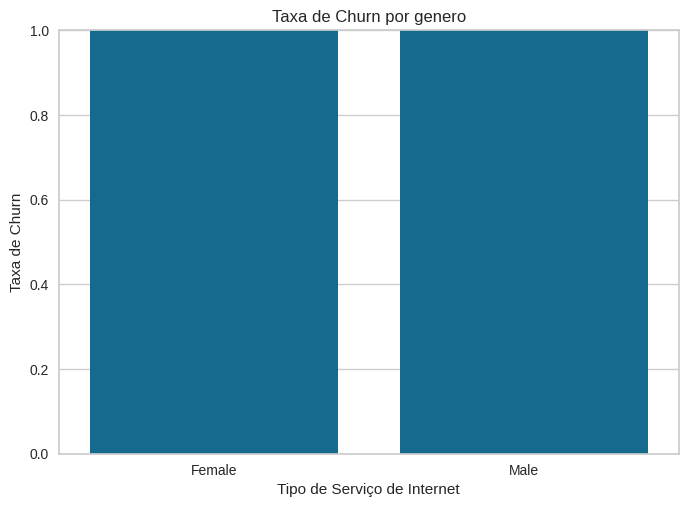

In [27]:
sns.barplot(x='gender', y='Churn_Rate', data=churn_rate_gender )
plt.title('Taxa de Churn por genero')
plt.xlabel('Tipo de Serviço de Internet')
plt.ylabel('Taxa de Churn')
plt.ylim(0, 1)  # Definir o limite do eixo y entre 0 e 1 para proporções
plt.show()

#####**➡️Churn por Idosos (SeniorCitizen)**

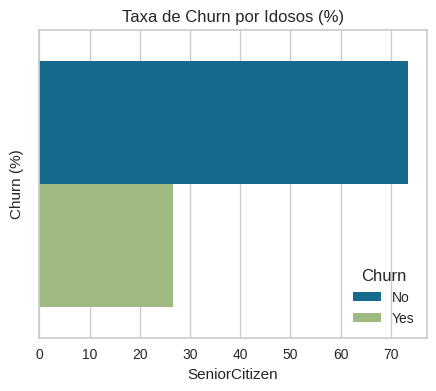

In [28]:
plt.figure(figsize=(5, 4))
sns.barplot(x='SeniorCitizen', hue='Churn', data=base_telco_df, estimator=lambda x: len(x) / len(base_telco_df) * 100, legend=True)
plt.title('Taxa de Churn por Idosos (%)')
plt.ylabel('Churn (%)')
plt.show()


#####**➡️Churn por Tipo de Internet (InternetService)**

In [29]:
# Calcular a taxa de churn por InternetService
churn_rate = base_telco_df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100

In [30]:
churn_rate

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [31]:
churn_rate = churn_rate['Yes'].reset_index().rename(columns={'Yes': 'Churn_Rate'})

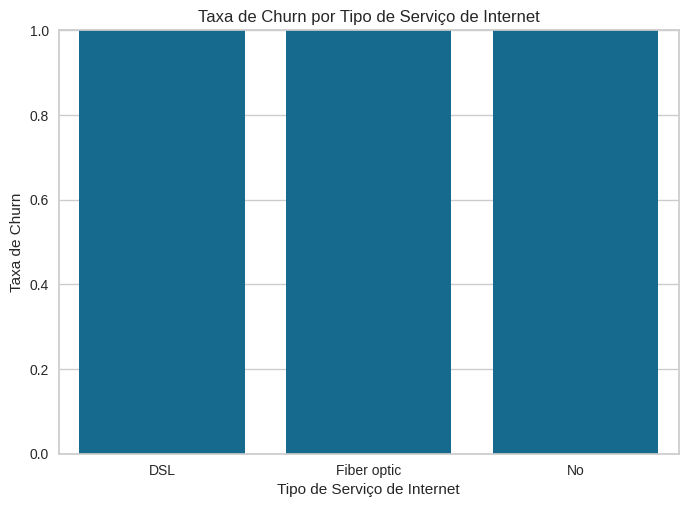

In [32]:
sns.barplot(x='InternetService', y='Churn_Rate', data=churn_rate)
plt.title('Taxa de Churn por Tipo de Serviço de Internet')
plt.xlabel('Tipo de Serviço de Internet')
plt.ylabel('Taxa de Churn')
plt.ylim(0, 1)  # Definir o limite do eixo y entre 0 e 1 para proporções
plt.show()

#####**➡️Churn por Tipo de Contrato (Contract)**

In [33]:
churn_rate_contract = base_telco_df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

In [34]:
churn_rate_contract = churn_rate_contract['Yes'].reset_index().rename(columns={'Yes': 'Churn_Rate'})

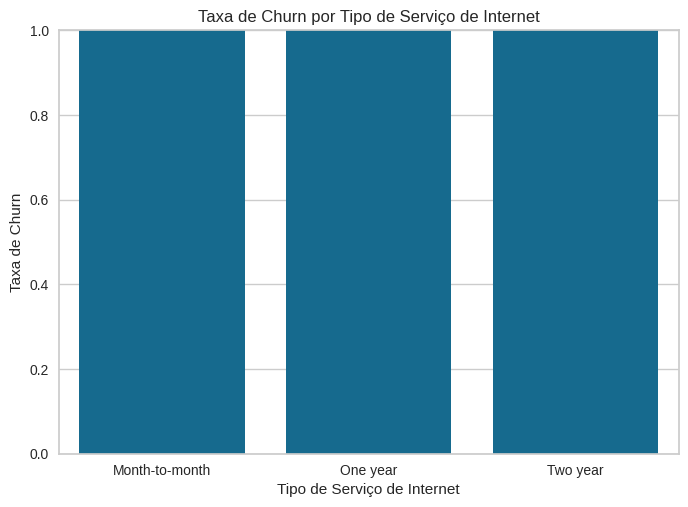

In [35]:
sns.barplot(x='Contract', y='Churn_Rate', data=churn_rate_contract)
plt.title('Taxa de Churn por Tipo de Serviço de Internet')
plt.xlabel('Tipo de Serviço de Internet')
plt.ylabel('Taxa de Churn')
plt.ylim(0, 1)  # Definir o limite do eixo y entre 0 e 1 para proporções
plt.show()

#####**➡️Churn por Método de pagamento(PaymentMethod)**

In [36]:
churn_rate_payment = base_telco_df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100

In [37]:
churn_rate_contract = churn_rate_payment['Yes'].reset_index().rename(columns={'Yes': 'Churn_Rate'})

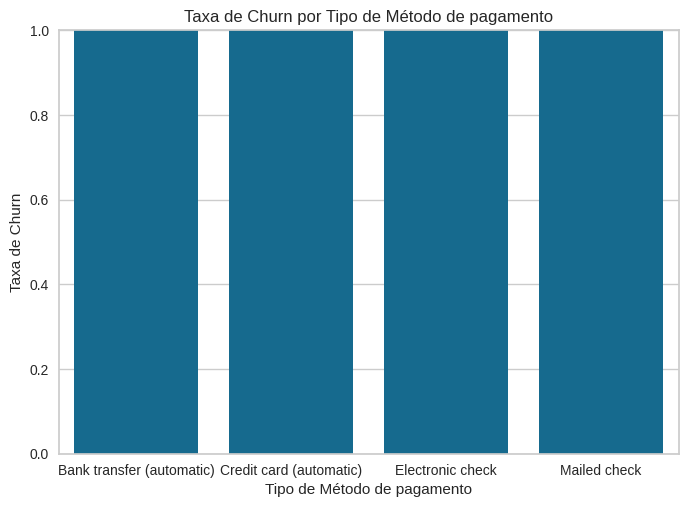

In [38]:
sns.barplot(x='PaymentMethod', y='Churn_Rate', data=churn_rate_contract)
plt.title('Taxa de Churn por Tipo de Método de pagamento')
plt.xlabel('Tipo de Método de pagamento')
plt.ylabel('Taxa de Churn')
plt.ylim(0, 1)  # Definir o limite do eixo y entre 0 e 1 para proporções
plt.show()

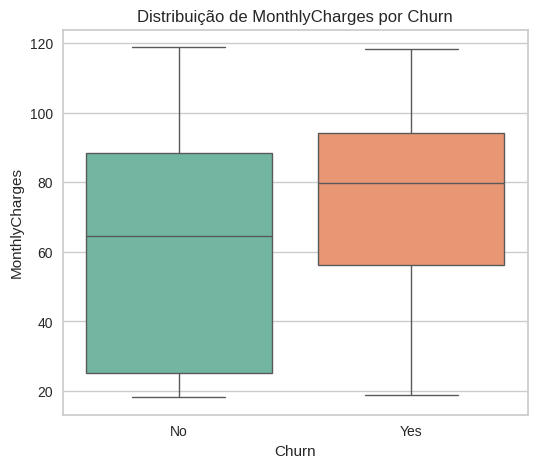

In [39]:

plt.figure(figsize=(6, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=base_telco_df, palette='Set2')
plt.title('Distribuição de MonthlyCharges por Churn')
plt.show()


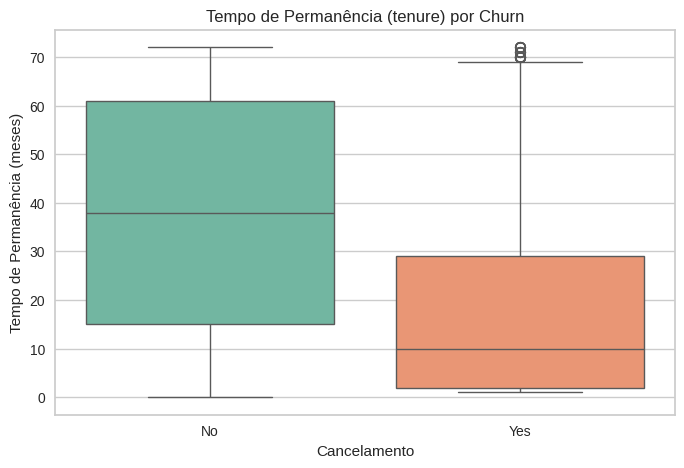

In [40]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='tenure', data=base_telco_df, palette='Set2')
plt.title('Tempo de Permanência (tenure) por Churn')
plt.ylabel('Tempo de Permanência (meses)')
plt.xlabel('Cancelamento')
plt.show()

#####**➡️Churn por serviço contratado(TypeService)**

In [41]:


# Serviços a serem analisados
services = ['PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']

# Loop para criar crosstabs
for service in services:
    print(f"\n--- {service} ---")
    crosstab = pd.crosstab(base_telco_df[service], base_telco_df['Churn'], margins=True, normalize='index') * 100
    print(crosstab)




--- PhoneService ---
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637
All           73.463013  26.536987

--- MultipleLines ---
Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896
All               73.463013  26.536987

--- InternetService ---
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980
All              73.463013  26.536987

--- OnlineSecurity ---
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194
All                  73.463013  26.536987

--- OnlineBackup

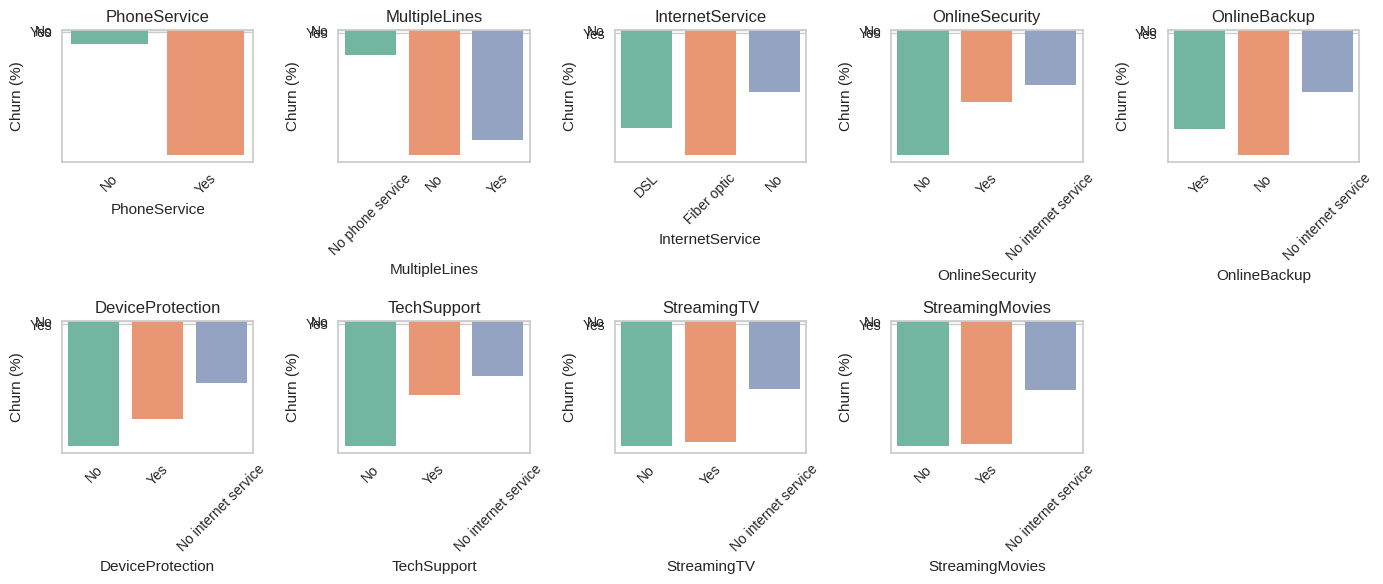

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Loop para gerar gráficos
for i, service in enumerate(services):
    plt.subplot(2, 5, i + 1)
    sns.barplot(x=service, y='Churn', data=base_telco_df, estimator=lambda x: len(x) / len(base_telco_df) * 100, ci=None, palette='Set2')
    plt.title(f'{service}')
    plt.ylabel('Churn (%)')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


#### Visualização de relações multivariadas

#####**➡️ Por Tipo de Contrato e Serviço de Internet**

In [43]:
import pandas as pd

crosstab = pd.crosstab([base_telco_df['Contract'], base_telco_df['InternetService']], base_telco_df['Churn'], margins=True,normalize='index')*100
print(crosstab)


Churn                                  No        Yes
Contract       InternetService                      
Month-to-month DSL              67.784137  32.215863
               Fiber optic      45.394737  54.605263
               No               81.106870  18.893130
One year       DSL              90.701754   9.298246
               Fiber optic      80.705009  19.294991
               No               97.527473   2.472527
Two year       DSL              98.089172   1.910828
               Fiber optic      92.773893   7.226107
               No               99.216301   0.783699
All                             73.463013  26.536987


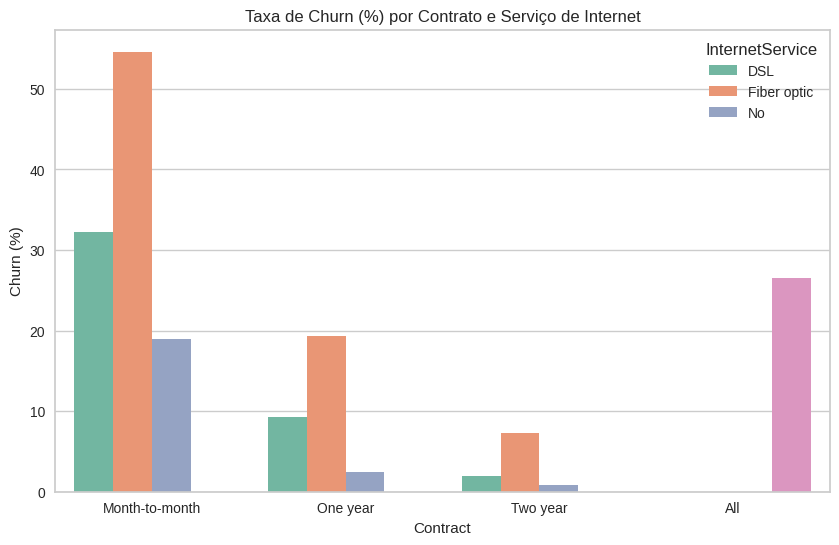

In [44]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Contract', y='Yes', hue='InternetService', data=crosstab, palette='Set2')
plt.title('Taxa de Churn (%) por Contrato e Serviço de Internet')
plt.ylabel('Churn (%)')
plt.show()

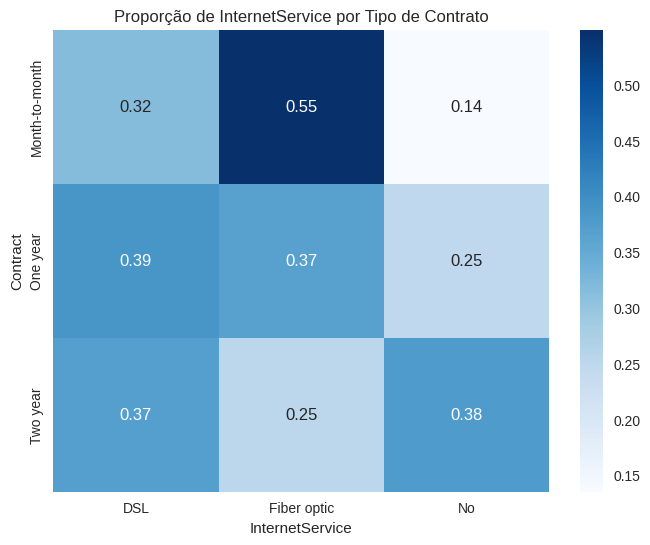

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
crosstab_percent = pd.crosstab(base_telco_df['Contract'], base_telco_df['InternetService'], normalize='index')
sns.heatmap(crosstab_percent, annot=True, cmap='Blues', fmt='.2f')
plt.title('Proporção de InternetService por Tipo de Contrato')
plt.show()


In [46]:
# Tabela cruzada entre PaymentMethod, PaperlessBilling e Churn
crosstab = pd.crosstab([base_telco_df['PaymentMethod'], base_telco_df['PaperlessBilling']], base_telco_df['Churn'], margins=True)
crosstab.columns = ['Não Cancelou', 'Cancelou', 'Total']
crosstab.index.names = ['Método de Pagamento', 'Fatura Digital']
crosstab


Não Cancelou  Cancelou  Total
Método de Pagamento       Fatura Digital                               
Bank transfer (automatic) No                       581        72    653
                          Yes                      705       186    891
Credit card (automatic)   No                       576        64    640
                          Yes                      714       168    882
Electronic check          No                       419       204    623
                          Yes                      875       867   1742
Mailed check              No                       827       129    956
                          Yes                      477       179    656
All                                               5174      1869   7043

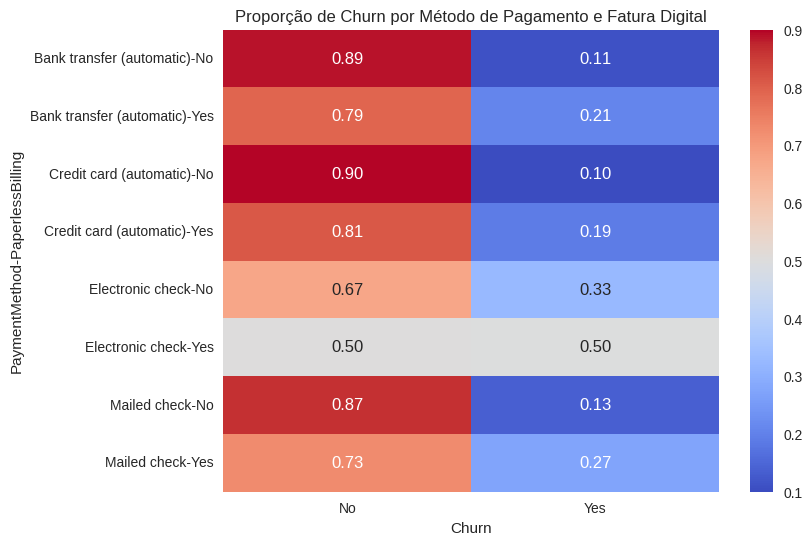

In [47]:
plt.figure(figsize=(8, 6))
crosstab_percent = pd.crosstab([base_telco_df['PaymentMethod'], base_telco_df['PaperlessBilling']], base_telco_df['Churn'], normalize='index')
sns.heatmap(crosstab_percent, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Proporção de Churn por Método de Pagamento e Fatura Digital')
plt.show()


#####**🔎 Análise Multivariada para: SeniorCitizen + Dependents + Churn**

**🔹 1️⃣ Tabela Cruzada (Crosstab):**

In [48]:
# Tabela cruzada entre SeniorCitizen, Dependents e Churn
crosstab_senior = pd.crosstab([base_telco_df['SeniorCitizen'], base_telco_df['Dependents']], base_telco_df['Churn'], margins=True)
crosstab_senior.columns = ['Não Cancelou', 'Cancelou', 'Total']
crosstab_senior.index.names = ['Idoso', 'Possui Dependentes']
crosstab_senior

Não Cancelou  Cancelou  Total
Idoso Possui Dependentes                               
0     No                          2793      1089   3882
      Yes                         1715       304   2019
1     No                           597       454   1051
      Yes                           69        22     91
All                               5174      1869   7043

**🔹 2️⃣ Heatmap para Visualização das Proporções:**

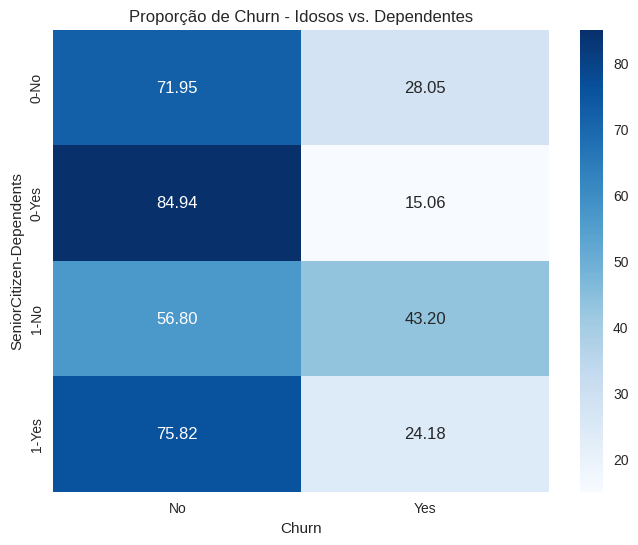

In [49]:
plt.figure(figsize=(8, 6))
crosstab_percent = pd.crosstab([base_telco_df['SeniorCitizen'], base_telco_df['Dependents']], base_telco_df['Churn'], normalize='index') * 100
sns.heatmap(crosstab_percent, annot=True, cmap='Blues', fmt='.2f')
plt.title('Proporção de Churn - Idosos vs. Dependentes')
plt.show()

**🔹 3️⃣ Teste Qui-Quadrado:**

Para confirmar se existe relação estatística.

In [50]:
# Tabela de contingência
contingency_table_senior = pd.crosstab([base_telco_df['SeniorCitizen'], base_telco_df['Dependents']], base_telco_df['Churn'])

# Aplicando o teste qui-quadrado
chi2, p, dof, expected = chi2_contingency(contingency_table_senior)

print(f"Valor de p: {p}")
if p < 0.05:
    print("Existe uma associação significativa entre Idoso, Dependentes e Churn.")
else:
    print("Não existe uma associação significativa entre Idoso, Dependentes e Churn.")

Valor de p: 9.005102944374082e-63
Existe uma associação significativa entre Idoso, Dependentes e Churn.


#####**🔎 Análise Multivariada para: TechSupport + OnlineSecurity + Churn**

A ideia é verificar se a ausência desses serviços aumenta a taxa de churn.

**🔹 1️⃣ Tabela Cruzada (Crosstab):**

Visualizando combinações de serviços de segurança online e suporte técnico.

In [51]:
# Tabela cruzada entre TechSupport, OnlineSecurity e Churn
crosstab_tech = pd.crosstab([base_telco_df['TechSupport'], base_telco_df['OnlineSecurity']], base_telco_df['Churn'], margins=True)
crosstab_tech.columns = ['Não Cancelou', 'Cancelou', 'Total']
crosstab_tech.index.names = ['Suporte Técnico', 'Segurança Online']
crosstab_tech


Não Cancelou  Cancelou  Total
Suporte Técnico     Segurança Online                                  
No                  No                           1303      1250   2553
                    Yes                           724       196    920
No internet service No internet service          1413       113   1526
Yes                 No                            734       211    945
                    Yes                          1000        99   1099
All                                              5174      1869   7043

**🔹 2️⃣ Heatmap para Visualização:**

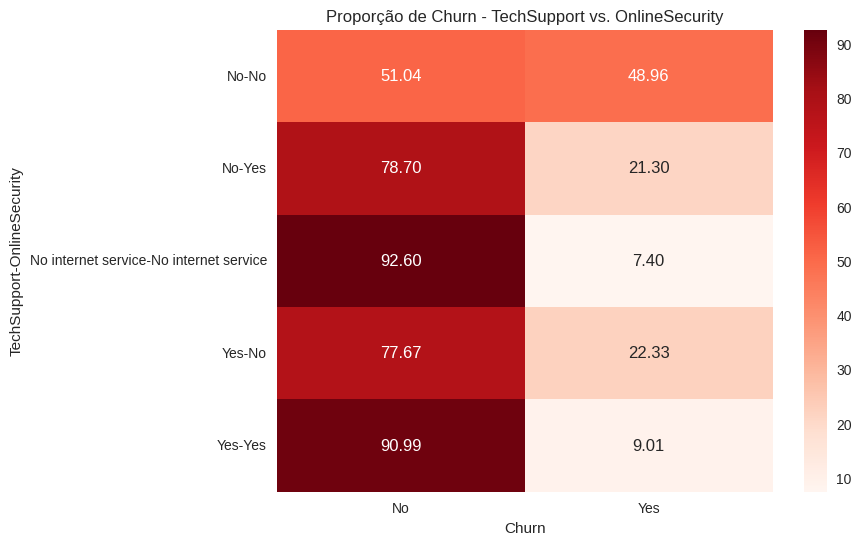

In [52]:
plt.figure(figsize=(8, 6))
crosstab_percent = pd.crosstab([base_telco_df['TechSupport'], base_telco_df['OnlineSecurity']], base_telco_df['Churn'], normalize='index') * 100
sns.heatmap(crosstab_percent, annot=True, cmap='Reds', fmt='.2f')
plt.title('Proporção de Churn - TechSupport vs. OnlineSecurity')
plt.show()


**🔹 3️⃣ Barplot Multivariado:**

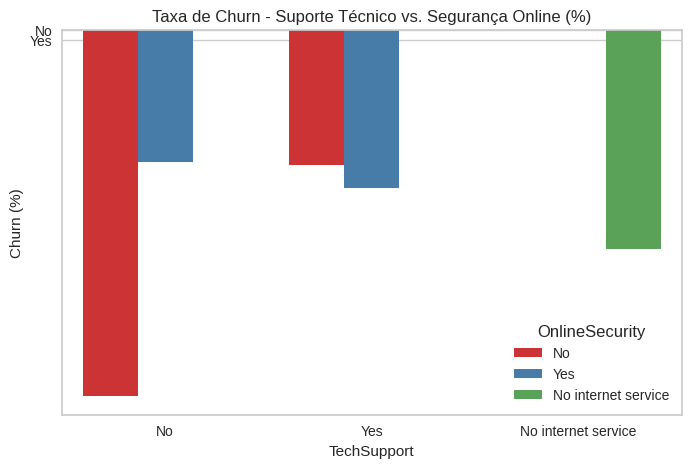

In [53]:
plt.figure(figsize=(8, 5))
sns.barplot(x='TechSupport', y='Churn', hue='OnlineSecurity', data=base_telco_df, estimator=lambda x: len(x) / len(base_telco_df) * 100, ci=None, palette='Set1')
plt.title('Taxa de Churn - Suporte Técnico vs. Segurança Online (%)')
plt.ylabel('Churn (%)')
plt.show()


**🔹 4️⃣ Teste Qui-Quadrado:**

In [54]:
# Tabela de contingência
contingency_table_tech = pd.crosstab([base_telco_df['TechSupport'], base_telco_df['OnlineSecurity']], base_telco_df['Churn'])

# Aplicando o teste qui-quadrado
chi2, p, dof, expected = chi2_contingency(contingency_table_tech)

print(f"Valor de p: {p}")
if p < 0.05:
    print("Existe uma associação significativa entre Suporte Técnico, Segurança Online e Churn.")
else:
    print("Não existe uma associação significativa entre Suporte Técnico, Segurança Online e Churn.")


Valor de p: 1.7839557471291298e-245
Existe uma associação significativa entre Suporte Técnico, Segurança Online e Churn.


In [55]:
base_telco_df.columns = base_telco_df.columns.str.replace(' ', '_')


In [56]:
# Substituir espaços nos nomes das colunas
base_telco_df.columns = base_telco_df.columns.str.replace(' ', '_')

# Substituir espaços nos valores das colunas categóricas
for col in base_telco_df.select_dtypes(include=['object']).columns:
    base_telco_df[col] = base_telco_df[col].str.replace(' ', '_')

# Copiar para o dataframe limpo
base_telco_df_clean = base_telco_df.copy()




## comparação de modelos com pycaret

In [57]:
from pycaret.classification import *
from imblearn.under_sampling import RandomUnderSampler
# Configurar PyCaret com undersampling
#undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
s_trees = setup(
    data=base_telco_df_clean,
    target='Churn',
    preprocess=True,
    normalize=False,
    #normalize_method='robust',
    transformation=True,
    remove_multicollinearity=True,
    fix_imbalance_method='smote',
    #fix_imbalance_method=undersampler,
    fix_imbalance=True,
    #feature_selection=True,
    #feature_selection_method='classic',
    #feature_selection_estimator='lightgbm',
    ignore_features=['customerID'],  # Ignora colunas como IDs que não agregam valor
    session_id=123
)

,Description,Value
0,Session id,123
1,Target,Churn
2,Target type,Binary
3,Target mapping,"No: 0, Yes: 1"
4,Original data shape,"(7043, 21)"
5,Transformed data shape,"(9357, 35)"
6,Transformed train set shape,"(7244, 35)"
7,Transformed test set shape,"(2113, 35)"
8,Ignore features,1
9,Numeric features,3


In [58]:
best_model = compare_models(
    sort='F1',  # Otimizar para F1-Score devido ao desbalanceamento
    n_select=1,  # Retornar apenas o melhor modelo
    include=['lr', 'rf', 'xgboost', 'lightgbm'],  # Modelos relevantes
    fold=10,  # Validação cruzada com 10 folds
    cross_validation=True  # Ativar validação cruzada
)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7850,0.8284,0.7850,0.7801,0.7813,0.4317,0.4338,1.8690
lightgbm,Light Gradient Boosting Machine,0.6897,0.7146,0.6897,0.7277,0.6993,0.2810,0.2910,2.7580
rf,Random Forest Classifier,0.7414,0.7684,0.7414,0.6962,0.6895,0.1647,0.1884,1.1210
xgboost,Extreme Gradient Boosting,0.7187,0.6917,0.7187,0.6893,0.6804,0.1545,0.1767,0.9110


Processing:   0%|          | 0/21 [00:00<?, ?it/s]

Avaliação inicial dos algoritmos


- Regressão logística: 78.50
- Light Gradient Boosting Machine: 68.97
- Random Forest Classifier: 74.14
- Extreme Gradient Boosting: 71.87


In [59]:
# Visualizar pipeline
pipeline = get_config('pipeline')
print("Pipeline completo:\n", pipeline)

# Visualizar etapas do pipeline
for step_name, step_obj in pipeline.steps:
    print(f"Etapa: {step_name}, Transformador: {step_obj}")

Pipeline completo:
 Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(exclude=None, include=None,
                                               transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['SeniorCitizen', 'tenure',
                                             'MonthlyCharges'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_fea...
                                    transformer=RemoveMulticollinearity(threshold=0.9))),
                ('balance',
                 TransformerWrapper(exclude=None, include=None,
                      

## Tratamento dos dados

In [60]:
X_data = base_telco_df_clean.drop('Churn', axis=1)
X_data = X_data.drop(columns=['customerID'])
X_data['TotalCharges'] = pd.to_numeric(X_data['TotalCharges'], errors='coerce')

y = base_telco_df_clean['Churn'].map({'Yes': 1, 'No': 0})




In [61]:
base_telco_df_clean['TotalCharges']

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.5
7039,7362.9
7040,346.45
7041,306.6


**balanceamento de classes**


In [62]:
categorical_cols = X_data.select_dtypes(include='object').columns

# Mostrar valores únicos por coluna categórica
for col in categorical_cols:
    print(f"\nColuna: {col}")
    print(X_data[col].unique())


Coluna: gender
['Female' 'Male']

Coluna: Partner
['Yes' 'No']

Coluna: Dependents
['No' 'Yes']

Coluna: PhoneService
['No' 'Yes']

Coluna: MultipleLines
['No_phone_service' 'No' 'Yes']

Coluna: InternetService
['DSL' 'Fiber_optic' 'No']

Coluna: OnlineSecurity
['No' 'Yes' 'No_internet_service']

Coluna: OnlineBackup
['Yes' 'No' 'No_internet_service']

Coluna: DeviceProtection
['No' 'Yes' 'No_internet_service']

Coluna: TechSupport
['No' 'Yes' 'No_internet_service']

Coluna: StreamingTV
['No' 'Yes' 'No_internet_service']

Coluna: StreamingMovies
['No' 'Yes' 'No_internet_service']

Coluna: Contract
['Month-to-month' 'One_year' 'Two_year']

Coluna: PaperlessBilling
['Yes' 'No']

Coluna: PaymentMethod
['Electronic_check' 'Mailed_check' 'Bank_transfer_(automatic)'
 'Credit_card_(automatic)']


In [63]:
numeric_cols = X_data.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    print(f"\nColuna: {col}")
    print(X_data[col].unique())


Coluna: SeniorCitizen
[0 1]

Coluna: tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

Coluna: MonthlyCharges
[29.85 56.95 53.85 ... 63.1  44.2  78.7 ]

Coluna: TotalCharges
[  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]


In [64]:
!ls


logs.log  process.py  sample_data  telco_customer_churn.csv


In [67]:
from process import DataPreprocessor

In [68]:
numeric_features = ['tenure','TotalCharges','MonthlyCharges']
categorical_features = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']
binary_feature = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','SeniorCitizen']

preprocessor = DataPreprocessor(numeric_features, categorical_features, binary_feature)
# Aplica a transformação
x_processed = preprocessor.data_transformer(X_data,fit=True)
X_res, y_res = preprocessor.apply_smote(x_processed, y)



In [69]:
#feature_names = preprocessor.get_feature_names()
#feature_names

In [70]:
x_processed

array([[-1.27744458, -0.99497138, -1.16032292, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.06632742, -0.17387565, -0.25962894, ...,  1.        ,
         0.        ,  0.        ],
       [-1.23672422, -0.96039939, -0.36266036, ...,  1.        ,
         1.        ,  0.        ],
       ...,
       [-0.87024095, -0.85518222, -1.1686319 , ...,  0.        ,
         1.        ,  0.        ],
       [-1.15528349, -0.87277729,  0.32033821, ...,  1.        ,
         1.        ,  1.        ],
       [ 1.36937906,  2.01391739,  1.35896134, ...,  1.        ,
         1.        ,  0.        ]])

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res , test_size=0.2, random_state=42)


## Salvar as variáveis

In [72]:
import pickle

In [73]:
with open('telco.pkl', mode = 'wb') as f:
  pickle.dump([X_train, y_train, X_test , y_test], f)

In [74]:
with open('telco.pkl', mode = 'wb') as f:
  pickle.dump([X_train, y_train, X_test, y_test], f)

# Random Forest

In [75]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier()
random_forest_model.fit(X_train, y_train)


RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=None,
                       oob_score=False, random_state=None, verbose=0,
                       warm_start=False)

In [76]:

y_pred_random_forest = random_forest_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_random_forest)
print(f"Acurácia: {accuracy:.2f}")


Acurácia: 0.86


# Regressão logística

In [77]:
logistic_model = LogisticRegression(random_state = 1)
logistic_model.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=1, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [78]:
y_pred_logistic = logistic_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_logistic)
print(f"Acurácia: {accuracy:.2f}")

Acurácia: 0.78


In [79]:
logistic_model.intercept_

array([-0.50530928])

In [80]:
logistic_model.coef_

array([[-1.57270702,  0.89094745, -0.7424877 , -0.21688118, -0.20793617,
         0.09977052, -0.65552805,  0.64569206, -0.31521083,  0.18274866,
        -0.31521083, -0.19258465,  0.03090948, -0.31521083, -0.04074547,
        -0.04110225, -0.31521083,  0.03126626,  0.12349725, -0.31521083,
        -0.13333324, -0.21011214, -0.31521083,  0.20027615, -0.24323062,
        -0.31521083,  0.23339463,  0.68570123, -0.0736369 , -0.93711115,
        -0.19180158, -0.22535401,  0.23492054, -0.14281178,  0.0056342 ,
         0.02106851, -0.32152216, -0.11711066,  0.33477189,  0.11889919]])

# XGBoost

In [81]:
model_XGBoost = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model_XGBoost.fit(X_train, y_train)

# 6. Avaliar modelo
y_pred = model_XGBoost.predict(X_test)

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Matriz de Confusão:
[[876 145]
 [149 900]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1021
           1       0.86      0.86      0.86      1049

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



# Redes Neurais

In [82]:
# 3 -> 100 -> 100 -> 1
# 3 -> 2 -> 2 -> 1
rede_neural_telco = MLPClassifier(max_iter=1500, verbose=True, tol=0.0000100,
                                   solver = 'adam', activation = 'relu',
                                   hidden_layer_sizes = (20,20))
rede_neural_telco.fit(X_train, y_train)

Iteration 1, loss = 0.57928356
Iteration 2, loss = 0.49882312
Iteration 3, loss = 0.47808435
Iteration 4, loss = 0.47143708
Iteration 5, loss = 0.46639434
Iteration 6, loss = 0.46318443
Iteration 7, loss = 0.46103659
Iteration 8, loss = 0.45839243
Iteration 9, loss = 0.45695063
Iteration 10, loss = 0.45506406
Iteration 11, loss = 0.45383481
Iteration 12, loss = 0.45332012
Iteration 13, loss = 0.45097405
Iteration 14, loss = 0.45030678
Iteration 15, loss = 0.44980385
Iteration 16, loss = 0.44792638
Iteration 17, loss = 0.44755757
Iteration 18, loss = 0.44620134
Iteration 19, loss = 0.44590620
Iteration 20, loss = 0.44405712
Iteration 21, loss = 0.44397120
Iteration 22, loss = 0.44188788
Iteration 23, loss = 0.44078568
Iteration 24, loss = 0.43960376
Iteration 25, loss = 0.43892171
Iteration 26, loss = 0.43864605
Iteration 27, loss = 0.43803133
Iteration 28, loss = 0.43562730
Iteration 29, loss = 0.43547998
Iteration 30, loss = 0.43442988
Iteration 31, loss = 0.43404332
Iteration 32, los

MLPClassifier(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
              beta_2=0.999, early_stopping=False, epsilon=1e-08,
              hidden_layer_sizes=(20, 20), learning_rate='constant',
              learning_rate_init=0.001, max_fun=15000, max_iter=1500,
              momentum=0.9, n_iter_no_change=10, nesterovs_momentum=True,
              power_t=0.5, random_state=None, shuffle=True, solver='adam',
              tol=1e-05, validation_fraction=0.1, verbose=True,
              warm_start=False)

In [83]:
previsoes_rede_neural = rede_neural_telco.predict(X_test)
previsoes_rede_neural

array([1, 1, 0, ..., 1, 1, 1])

In [84]:
from sklearn.metrics import accuracy_score, classification_report
accuracy_score(previsoes_rede_neural, previsoes_rede_neural)

1.0

0.8135265700483092

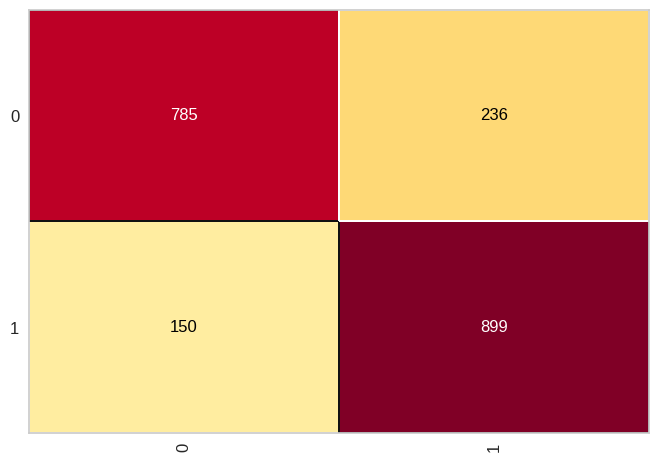

In [85]:
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(rede_neural_telco)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

# Avaliação dos algoritmos


- Random forest: 86.00
- XGBoost : 86.00
- Regressão logística: 78.00
- Redes neurais: 81.35

## Tuning dos parâmetros com Optuna

In [86]:
with open('telco.pkl', 'rb') as f:
  X_train, y_train, X_test, y_test = pickle.load(f)

In [87]:
X_train.shape, y_train.shape

((8278, 40), (8278,))

In [88]:
X_test.shape, y_test.shape

((2070, 40), (2070,))

In [117]:
X_telco = np.concatenate((X_train, X_test), axis = 0)
X_telco.shape

(10348, 40)

In [90]:
X_telco

array([[-1.27744458, -0.98583166, -0.47233896, ...,  1.        ,
         0.        ,  1.        ],
       [-0.82952058, -0.90715059, -1.51096208, ...,  1.        ,
         0.        ,  0.        ],
       [-0.92730202, -0.61300667,  0.98373043, ...,  1.        ,
         0.19956975,  0.        ],
       ...,
       [-1.27744458, -0.99245465, -0.97087806, ...,  0.        ,
         1.        ,  0.        ],
       [-1.27744458, -0.98792894, -0.63020967, ...,  1.        ,
         1.        ,  0.        ],
       [-1.197665  , -0.92691148, -0.23749792, ...,  1.        ,
         1.        ,  0.        ]])

In [111]:
y_telco = np.array(np.concatenate((y_train, y_test), axis=0), copy=True)
y_telco.shape

(10348,)

In [118]:
y_telco = np.concatenate((y_train, y_test), axis = 0)
y_telco.shape

(10348,)

In [92]:
y_telco

array([1, 0, 1, ..., 1, 0, 1])

### Random forest

In [112]:
import optuna
def objective_rf(trial):
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    n_estimators = trial.suggest_categorical('n_estimators', [10, 40, 100, 150])
    min_samples_split = trial.suggest_categorical('min_samples_split', [2, 5, 10])
    min_samples_leaf = trial.suggest_categorical('min_samples_leaf', [1, 5, 10])

    model = RandomForestClassifier(
        criterion=criterion,
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    return score.mean()

In [113]:
study = optuna.create_study(direction='maximize')  # maximize acurácia
study.optimize(objective_rf, n_trials=50)

print(study.best_params)
print(study.best_value)

{'criterion': 'entropy', 'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1}
0.8456158413483846


### Regressão logística

In [114]:
from sklearn.pipeline import Pipeline

In [119]:
# Converter para arrays mutáveis
X_train = np.array(X_train, copy=True)
y_train = np.array(y_train, copy=True)
X_test  = np.array(X_test, copy=True)
y_test  = np.array(y_test, copy=True)

In [127]:
def objective_rl(trial):
    tol = trial.suggest_categorical('tol', [0.0001, 0.00001, 0.000001])
    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet", None])
    C = trial.suggest_loguniform("C", 1e-4, 1e2)
    solver = trial.suggest_categorical("solver", ["liblinear", "saga", "lbfgs", "newton-cg", "sag"])

    # Regras de compatibilidade
    if penalty in ["l1", "elasticnet"] and solver not in ["liblinear", "saga"]:
        raise optuna.exceptions.TrialPruned()
    if penalty is None and solver in ["liblinear"]:
        raise optuna.exceptions.TrialPruned()
    if penalty == "elasticnet" and solver not in ["saga"]:
        raise optuna.exceptions.TrialPruned()

    if penalty == "elasticnet":
        l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)
    else:
        l1_ratio = None

    # Pipeline com padronização + regressão
    model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty=penalty,
        C=C,
        solver=solver,
        l1_ratio=l1_ratio,
        max_iter=1000,
        random_state=42))
    ])


    # Avaliação com cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc').mean()
    return score

In [128]:
# Executar estudo
study = optuna.create_study(direction="maximize")
study.optimize(objective_rl, n_trials=100)

# Mostrar melhores hiperparâmetros
print("Melhores hiperparâmetros:")
print(study.best_params)
print(f"AUC: {study.best_value:.4f}")

Melhores hiperparâmetros:
{'tol': 0.0001, 'penalty': 'elasticnet', 'C': 2.296106062998815, 'solver': 'saga', 'l1_ratio': 0.7987587818332604}
AUC: 0.8552


### XGBoost

In [129]:
def objective_xgb(trial):

  param = {
        'verbosity': 0,
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float("gamma", 0, 1, step=0.2),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }

  model_XGBoost = XGBClassifier(**param)
  score = cross_val_score(model_XGBoost, X_train, y_train, cv=3, scoring='accuracy')
  return score.mean()  # objetivo é maximizar a acurácia

study = optuna.create_study(direction='maximize')  # maximize acurácia
study.optimize(objective_xgb, n_trials=50)

print(study.best_params)
print(study.best_value)

{'max_depth': 9, 'min_child_weight': 2, 'gamma': 0.6000000000000001, 'learning_rate': 0.03292424060927919, 'n_estimators': 389, 'subsample': 0.586850722356481, 'colsample_bytree': 0.5993480631065589}
0.8604735840367844


In [130]:
study = optuna.create_study(direction='maximize')  # maximize acurácia
study.optimize(objective_xgb, n_trials=50)

print(study.best_params)
print(study.best_value)

{'max_depth': 10, 'min_child_weight': 4, 'gamma': 0.6000000000000001, 'learning_rate': 0.027441402527142222, 'n_estimators': 500, 'subsample': 0.7821110524178002, 'colsample_bytree': 0.5669395532980072}
0.8568497390183728


### Redes Neurais

In [131]:
def objective_mlp(trial):
    activation = trial.suggest_categorical('activation', ['relu', 'logistic', 'tanh'])
    solver = trial.suggest_categorical('solver', ['adam', 'sgd'])
    batch_size = trial.suggest_categorical('batch_size', [10, 56])

    model = MLPClassifier(
        activation=activation,
        solver=solver,
        batch_size=batch_size,
        max_iter=300,
        random_state=42
    )

    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    return score.mean()

In [132]:
study = optuna.create_study(direction='maximize')  # maximize acurácia
study.optimize(objective_mlp, n_trials=50)

print(study.best_params)
print(study.best_value)

{'activation': 'relu', 'solver': 'adam', 'batch_size': 56}
0.8138441079085924


## Validação cruzada

In [133]:
from sklearn.model_selection import cross_val_score, KFold

In [135]:

resultados_random_forest = []
resultados_xgboost = []
resultados_logistica = []
resultados_rede_neural = []

for i in range(30):
  print(i)
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)

  random_forest = RandomForestClassifier(criterion = 'entropy', min_samples_leaf = 1, min_samples_split=5, n_estimators = 100)
  scores = cross_val_score(random_forest, X_telco, y_telco, cv = kfold)
  resultados_random_forest.append(scores.mean())

  logistic = LogisticRegression(C = 2.296106062998815, solver = 'saga', tol = 0.0001,penalty = 'elasticnet',l1_ratio = 0.7987587818332604)
  scores = cross_val_score(logistic, X_telco, y_telco, cv = kfold)
  resultados_logistica.append(scores.mean())

  XGboost = XGBClassifier(colsample_bytree = 0.5669395532980072, gamma = 0.6000000000000001, max_depth = 10, min_child_weight = 4, reg_alpha = 1.0, subsample= 0.7821110524178002,n_estimators = 500)
  scores = cross_val_score(XGboost, X_telco, y_telco, cv = kfold)
  resultados_xgboost.append(scores.mean())

  rede_neural = MLPClassifier(activation = 'relu', batch_size = 56, solver = 'adam')
  scores = cross_val_score(rede_neural, X_telco, y_telco, cv = kfold)
  resultados_rede_neural.append(scores.mean())


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


In [136]:
resultados = pd.DataFrame({ 'Random forest': resultados_random_forest,
                            'Logistica': resultados_logistica,
                            'Rede neural': resultados_rede_neural,
                            'XGBoost': resultados_xgboost
                            })

resultados

,Random forest,Logistica,Rede neural,XGBoost
0,0.858038,0.775028,0.826052,0.851081
1,0.858911,0.774641,0.831562,0.851857
2,0.859971,0.774353,0.828275,0.849728
3,0.858233,0.774157,0.828082,0.853208
4,0.857654,0.774738,0.835043,0.853691
5,0.858425,0.775318,0.826925,0.851950
6,0.858908,0.774448,0.824988,0.852242
7,0.858911,0.775705,0.831175,0.850697
8,0.859295,0.774351,0.830981,0.849730
9,0.857945,0.774837,0.828469,0.847022


In [137]:
resultados.describe()

,Random forest,Logistica,Rede neural,XGBoost
count,30.000000,30.000000,30.000000,30.000000
mean,0.858446,0.774716,0.829458,0.851028
std,0.000915,0.000778,0.002677,0.001944
min,0.856494,0.772710,0.823541,0.847022
25%,0.857775,0.774281,0.827574,0.849729
50%,0.858425,0.774787,0.829678,0.850793
75%,0.859126,0.775102,0.831319,0.852025
max,0.860459,0.776674,0.835043,0.855625


In [138]:
resultados.var()

,0
Random forest,8.378019e-07
Logistica,6.048764e-07
Rede neural,7.164525e-06
XGBoost,3.778862e-06


In [139]:
(resultados.std() / resultados.mean()) * 100

,0
Random forest,0.106625
Logistica,0.100390
Rede neural,0.322700
XGBoost,0.228421


## Teste de hipótese com ANOVA e Tukey

verificando se existe diferença significativa entre os modelos

In [140]:
from scipy.stats import f_oneway

In [141]:
_, p = f_oneway(resultados_random_forest,resultados_logistica, resultados_rede_neural)
p

1.5860828022910467e-115

In [142]:
alpha = 0.05
if p <= alpha:
  print('Hipótese nula rejeitada. Dados são diferentes')
else:
  print('Hipótese alternativa rejeitada. Resultados são iguais')

Hipótese nula rejeitada. Dados são diferentes


# Salvar um classificador já treinado

In [ ]:
import pickle
pickle.dump(random_forest, open('random_forest_finalizado.sav', 'wb'))
pickle.dump(logistic open('logistic.sav', 'wb'))
pickle.dump(rede_neural, open('neural_network.sav', 'wb'))
pickle.dump(XGboost, open('XGboost.sav', 'wb'))